# Intro
## Business Context

The product team hypothesized that friction in the checkout process and
low visibility of promotional content were reducing conversion rates on
the furniture e-commerce platform.

Four independent experiments were launched simultaneously during the peak
season (November 2020 – January 2021) to test different UX interventions:

**Test 1 — Simplified Checkout Flow**
The team introduced a redesigned checkout page with a progress bar,
auto-fill for shipping and payment fields, and a persistent order summary
panel. The hypothesis was that reducing cognitive load at the payment stage
would increase the share of users completing each checkout step.

- **H₀:** The redesigned checkout has no effect on checkout funnel conversion rates.
- **H₁:** The redesigned checkout increases conversion rates for begin_checkout,
add_shipping_info, and add_payment_info compared to the control.

**Test 2 — Promotional Banner Repositioning**
The team moved the promotional banner from the sidebar to a sticky
bottom bar visible on all product pages. The hypothesis was that increased
banner visibility would drive more add-to-cart actions.

- **H₀:** Repositioning the promotional banner has no effect on add_to_cart
and view_promotion rates.
- **H₁:** The new banner position increases add_to_cart and view_promotion
conversion rates.

**Test 3 — Personalized Promotion Targeting**
The team tested showing personalized promotions based on browsing history
instead of generic site-wide banners. The hypothesis was that relevance
would increase engagement with promotions and add-to-cart actions.

- **H₀:** Personalized promotions have no effect on view_promotion,
select_promotion, and add_to_cart rates.
- **H₁:** Personalized promotions increase engagement with promotional
content and add-to-cart conversion.

**Test 4 — Mandatory Registration Before Checkout**
The team tested requiring users to create an account before proceeding
to checkout, hypothesizing this would increase new account registrations
without significantly harming checkout conversion.

- **H₀:** Mandatory registration has no effect on new_accounts and
begin_checkout rates.
- **H₁:** Mandatory registration increases new_accounts without
negatively affecting begin_checkout conversion.

Dataset covers sessions from 2020-11-01 - 2021-01-27.
Four independent A/B tests were analyzed. Test group 1 = control,
test group 2 = variant. Significance level: α = 0.05.

In [8]:
!pip install --upgrade google-cloud-bigquery
from google.colab import auth
from google.cloud import bigquery
auth.authenticate_user()
client = bigquery.Client(project="data-analytics-mate")


query="""
with session_info as (                               -- session_info: base table joining ab_test, session, session_params
 SELECT
       s.date,
       s.ga_session_id,
       sp.country,
       sp.continent,
       sp.device,
       sp.channel,
       ab.test,
       ab.test_group,
 FROM `DA.ab_test` ab
 JOIN `DA.session` s
 ON ab.ga_session_id = s.ga_session_id
 JOIN `DA.session_params` sp
 ON sp.ga_session_id = ab.ga_session_id
),
session_with_orders as (                               -- session_with_orders: counts distinct sessions that resulted in an order
SELECT
       session_info.date,
       session_info.country,
       session_info.continent,
       session_info.device,
       session_info.channel,
       session_info.test,
       session_info.test_group,
       COUNT(DISTINCT o.ga_session_id) as session_with_orders
FROM `DA.order` o
JOIN session_info
ON o.ga_session_id = session_info.ga_session_id
GROUP BY   session_info.date,
       session_info.country,
       session_info.continent,
       session_info.device,
       session_info.channel,
       session_info.test,
       session_info.test_group
),
events as (                                   -- events: aggregates all tracked events per session
SELECT
       session_info.date,
       session_info.country,
       session_info.continent,
       session_info.device,
       session_info.channel,
       session_info.test,
       session_info.test_group,
       ep.event_name,
       COUNT(ep.ga_session_id) as event_cnt
FROM `DA.event_params` ep
JOIN session_info
ON ep.ga_session_id = session_info.ga_session_id
GROUP BY  session_info.date,
       session_info.country,
       session_info.continent,
       session_info.device,
       session_info.channel,
       session_info.test,
       session_info.test_group,
       ep.event_name
),
session as (                                    -- session: counts total sessions (denominator for all metrics)
SELECT
     session_info.date,
       session_info.country,
       session_info.continent,
       session_info.device,
       session_info.channel,
       session_info.test,
       session_info.test_group,
       COUNT(DISTINCT session_info.ga_session_id) as  session_cnt
FROM session_info
GROUP BY session_info.date,
       session_info.country,
       session_info.continent,
       session_info.device,
             session_info.channel,
       session_info.test,
       session_info.test_group
),
accounts as (                                                      -- accounts: counts new account registrations per session
SELECT session_info.date,
       session_info.country,
       session_info.continent,
       session_info.device,
       session_info.channel,
       session_info.test,
       session_info.test_group,
       COUNT(DISTINCT acs.account_id) as new_account
FROM `DA.account_session` acs
JOIN session_info
ON acs.ga_session_id = session_info.ga_session_id
GROUP BY session_info.date,
       session_info.country,
       session_info.continent,
       session_info.device,
       session_info.channel,
       session_info.test,
       session_info.test_group
)
SELECT
       session_with_orders.date,
       session_with_orders.country,
       session_with_orders.continent,
       session_with_orders.device,
       session_with_orders.channel,
       session_with_orders.test,
       session_with_orders.test_group,
       'session with orders' as event_name,
       session_with_orders.session_with_orders as value
FROM session_with_orders
UNION ALL
SELECT  events.date,
       events.country,
       events.continent,
       events.device,
       events.channel,
       events.test,
       events.test_group,
       events.event_name,
       events.event_cnt as value
FROM events
UNION ALL
SELECT session.date,
       session.country,
       session.continent,
       session.device,
       session.channel,
       session.test,
       session.test_group,
       'session' as event_name,
       session.session_cnt as value
FROM session
UNION ALL
SELECT
       accounts.date,
       accounts.country,
       accounts.continent,
       accounts.device,
       accounts.channel,
       accounts.test,
       accounts.test_group,
       'accounts' as event_name,
       accounts.new_account as value
FROM accounts
"""
query_job = client.query(query)
results = query_job.result()
df = results.to_dataframe()
df.to_csv('data_frame.csv', index=False)
df.head()


,date,country,continent,device,channel,test,test_group,event_name,value
0,2020-11-06,Slovakia,Europe,mobile,Paid Search,2,2,session with orders,1
1,2020-11-06,Slovakia,Europe,mobile,Paid Search,1,2,session with orders,1
2,2020-12-09,El Salvador,Americas,mobile,Direct,4,2,session with orders,1
3,2020-12-09,El Salvador,Americas,mobile,Direct,3,2,session with orders,1
4,2020-12-21,Slovakia,Europe,mobile,Organic Search,4,2,session with orders,1


In [9]:
# EDA
df.info()
df.describe()
df.isna().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 800996 entries, 0 to 800995
Data columns (total 9 columns):
 #   Column      Non-Null Count   Dtype 
---  ------      --------------   ----- 
 0   date        800996 non-null  dbdate
 1   country     800996 non-null  object
 2   continent   800996 non-null  object
 3   device      800996 non-null  object
 4   channel     800996 non-null  object
 5   test        800996 non-null  Int64 
 6   test_group  800996 non-null  Int64 
 7   event_name  800996 non-null  object
 8   value       800996 non-null  Int64 
dtypes: Int64(3), dbdate(1), object(5)
memory usage: 57.3+ MB


,0
date,0
country,0
continent,0
device,0
channel,0
test,0
test_group,0
event_name,0
value,0


In [10]:
# Summary EDA
print(f"Date range: {df['date'].min()} — {df['date'].max()}")
print(f"Tests: {sorted(df['test'].unique())}")
print(f"Test groups: {sorted(df['test_group'].unique())}")
print(f"Events tracked: {sorted(df['event_name'].unique())}")
print(f"Continents: {sorted(df['continent'].unique())}")
print(f"Devices: {sorted(df['device'].unique())}")
print(f"Channels: {sorted(df['channel'].unique())}")

Date range: 2020-11-01 — 2021-01-27
Tests: [np.int64(1), np.int64(2), np.int64(3), np.int64(4)]
Test groups: [np.int64(1), np.int64(2)]
Events tracked: ['accounts', 'add_payment_info', 'add_shipping_info', 'add_to_cart', 'begin_checkout', 'click', 'first_visit', 'page_view', 'scroll', 'select_item', 'select_promotion', 'session', 'session with orders', 'session_start', 'user_engagement', 'view_item', 'view_item_list', 'view_promotion', 'view_search_results']
Continents: ['(not set)', 'Africa', 'Americas', 'Asia', 'Europe', 'Oceania']
Devices: ['desktop', 'mobile', 'tablet']
Channels: ['Direct', 'Organic Search', 'Paid Search', 'Social Search', 'Undefined']


## EDA Summary

**Dataset shape:** 800,996 rows × 9 columns

**Date range:** 2020-11-01 - 2021-01-27

**Tests:** 4 independent A/B tests (test numbers: 1, 2, 3, 4)

**Test groups:** 2 (1 = control, 2 = variant)

**Missing values:** none - dataset is complete

**Data types:**
- Datetime: date
- Categorical: country, continent, device, channel, event_name
- Integer: test, test_group, value

**Memory usage:** 57.3 MB

In [11]:

import pandas as pd
import numpy as np
from scipy import stats
from statsmodels.stats.proportion import proportions_ztest
import matplotlib.pyplot as plt
import seaborn as sns



# reshape from long format (all metrics in one column) into wide format (each metric in its own column)
df_wide = df.pivot_table(index=["test","test_group","country","continent","device","channel","date"],columns="event_name",values="value",aggfunc="sum",fill_value=0).reset_index()
print(df_wide.columns.tolist())
print("test", df_wide["test"].unique())
print("test_group",df_wide["test_group"].unique())



# Agg Metrics with numerator (event) and denominator (session)

metrics = [
    {"name": "add_payment_info/session", "num":"add_payment_info", "den":"session"}, #  funnel purchase metrics
    {"name": "add_shipping_info/session", "num":"add_shipping_info", "den":"session"},
    {"name": "begin_checkout/session", "num":"begin_checkout", "den":"session"},
    {"name": "new_accounts/session", "num":"accounts", "den":"session"},
    {"name": "orders/session", "num":"session with orders", "den":"session"},
    {"name": "view_promotion/session", "num":"view_promotion", "den":"session"}, # Promotion-related metrics
    {"name": "select_promotion/session", "num":"select_promotion", "den":"session"},
    {"name": "add_to_cart/session", "num":"add_to_cart", "den":"session"}]

def aggregate_metrics(df, breakdown_cols=["test","test_group"]):
    results = []
    for m in metrics:
        agg = df.groupby(breakdown_cols).agg(
            numerator=(m["num"], "sum"),
            denominator=(m["den"], "sum")
        ).reset_index()
        agg["metric"] = m["name"]
        results.append(agg)
    return pd.concat(results, ignore_index=True)

summary = aggregate_metrics(df_wide, breakdown_cols=["test","test_group"])


['test', 'test_group', 'country', 'continent', 'device', 'channel', 'date', 'accounts', 'add_payment_info', 'add_shipping_info', 'add_to_cart', 'begin_checkout', 'click', 'first_visit', 'page_view', 'scroll', 'select_item', 'select_promotion', 'session', 'session with orders', 'session_start', 'user_engagement', 'view_item', 'view_item_list', 'view_promotion', 'view_search_results']
test <IntegerArray>
[1, 2, 3, 4]
Length: 4, dtype: Int64
test_group <IntegerArray>
[1, 2]
Length: 2, dtype: Int64


## Metrics  Sheet
Metrics used in the analysis:

###Conversion Funnel Metrics


- add_payment_info/session  
  Numerator: number of `add_payment_info` events.  
  Denominator: total number of sessions.  
  Interpretation: shows the share of users who entered payment information. This is a mid‑funnel step before completing an order.

- add_shipping_info/session  
  Numerator: number of `add_shipping_info` events.  
  Denominator: total number of sessions.  
  Interpretation: shows the share of users who entered shipping details. Indicates readiness to finalize a purchase.

- begin_checkout/session  
  Numerator: number of `begin_checkout` events.  
  Denominator: total number of sessions.  
  Interpretation: shows the share of users who started the checkout process. A critical step in the purchase funnel.

- new_accounts/session  
  Numerator: number of new account sign-ups (`accounts`).  
  Denominator: total number of sessions.  
  Interpretation: shows the share of sessions that resulted in new customer registrations. Important for acquisition.

- orders/session  
  Numerator: number of sessions with completed orders.(`session with orders`)  
  Denominator: total number of sessions.  
  Interpretation: shows the share of users who completed a purchase. This is the final conversion metric.


### Promo metrics

- view_promotion/session  
  Numerator: number of `view_promotion` events.  
  Denominator: total number of sessions.  
  Interpretation: shows how often users saw promotions during their sessions. Reflects visibility of marketing content.

- select_promotion/session  
  Numerator: number of `select_promotion` events.  
  Denominator: total number of sessions.  
  Interpretation: shows how often users interacted with promotions (clicked or selected). Reflects promotional effectiveness.

- add_to_cart/session  
  Numerator: number of `add_to_cart` events.  
  Denominator: total number of sessions.  
  Interpretation: shows the share of users who added items to their cart. A key indicator of purchase intent.


### Explanation
- __Numerator (number of events)__ - how many times the event occurred.
- __Denominator (number of sessions)__ - total number of sessions in which the event could occur.
- __Metric name__ - formula in the form _event/session_.


In [12]:


results = []

for m in metrics:
    merged = df_wide.groupby(["test","test_group"])[[m["num"], m["den"]]].sum().reset_index()
    merged = merged.rename(columns={m["num"]: "numerator", m["den"]: "denominator"})

    for test_id in merged["test"].unique():
        subset = merged[merged["test"] == test_id]
        if subset["test_group"].nunique() != 2:
            continue

        a = subset[subset["test_group"] == 1].iloc[0]
        b = subset[subset["test_group"] == 2].iloc[0]

        # Direct call
        count = [a["numerator"], b["numerator"]]
        nobs = [a["denominator"], b["denominator"]]
        z_stat, p_value = proportions_ztest(count, nobs, alternative="two-sided")

        results.append({
            "test_number": test_id,
            "metric": m["name"],
            "numerator_control": a["numerator"],
            "denominator_control": a["denominator"],
            "conversion_rate_control": a["numerator"]/a["denominator"],
            "numerator_test": b["numerator"],
            "denominator_test": b["denominator"],
            "conversion_rate_test": b["numerator"]/b["denominator"],
            "metric_change": (b["numerator"]/b["denominator"] - a["numerator"]/a["denominator"]) / (a["numerator"]/a["denominator"]),
            "z_stat": z_stat,
            "p_value": p_value,
            "significant": p_value < 0.05
        })

final_df = pd.DataFrame(results)
final_df = final_df.round(6)


# Value round
final_df["conversion_rate_control"] = final_df["conversion_rate_control"].round(6)
final_df["conversion_rate_test"] = final_df["conversion_rate_test"].round(6)
final_df["metric_change"] = final_df["metric_change"].round(6)
final_df["z_stat"] = final_df["z_stat"].round(6)
final_df["p_value"] = final_df["p_value"].round(6)

final_df





,test_number,metric,numerator_control,denominator_control,conversion_rate_control,numerator_test,denominator_test,conversion_rate_test,metric_change,z_stat,p_value,significant
0,1,add_payment_info/session,1988,45362,0.043825,2229,45193,0.049322,0.125420,-3.924884,0.000087,True
1,2,add_payment_info/session,2344,50637,0.046290,2409,50244,0.047946,0.035769,-1.240994,0.214608,False
2,3,add_payment_info/session,3623,70047,0.051722,3697,70439,0.052485,0.014746,-0.643172,0.520112,False
3,4,add_payment_info/session,3731,105079,0.035507,3601,105141,0.034249,-0.035412,1.571106,0.116158,False
4,1,add_shipping_info/session,3034,45362,0.066884,3221,45193,0.071272,0.065605,-2.603571,0.009226,True
5,2,add_shipping_info/session,3480,50637,0.068724,3510,50244,0.069859,0.016510,-0.709557,0.477979,False
6,3,add_shipping_info/session,5298,70047,0.075635,5188,70439,0.073652,-0.026212,1.413727,0.157442,False
7,4,add_shipping_info/session,5128,105079,0.048801,4956,105141,0.047137,-0.034111,1.785795,0.074132,False
8,1,begin_checkout/session,3784,45362,0.083418,4021,45193,0.088974,0.066606,-2.978783,0.002894,True
9,2,begin_checkout/session,4262,50637,0.084168,4313,50244,0.085841,0.019882,-0.952898,0.340642,False


In [13]:
from google.colab import sheets
sheet = sheets.InteractiveSheet(df=final_df)

https://docs.google.com/spreadsheets/d/1GkuvxGqDNRNrZ_wbfjnHHlf3vq6xeXIF9fUyH3COaNU/edit#gid=0


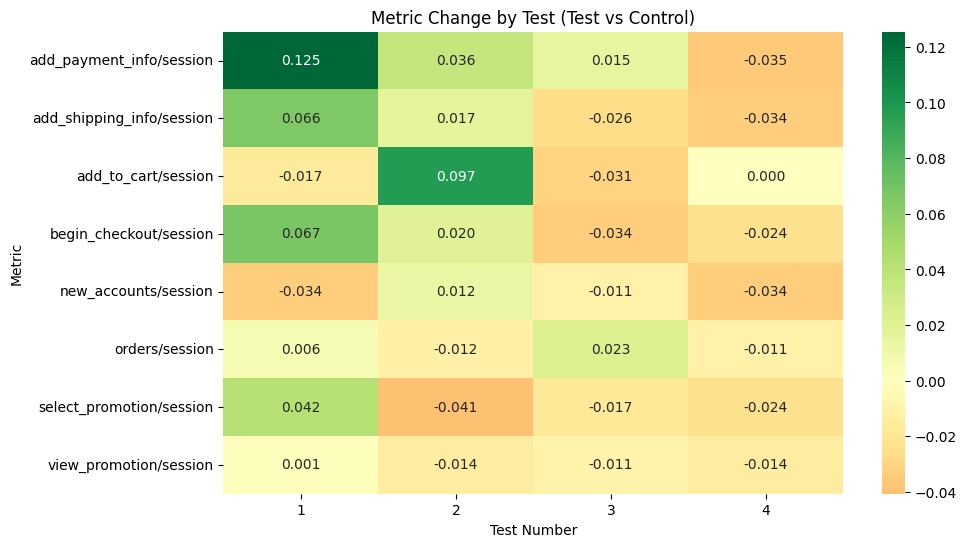

In [ ]:
# Heatmap: difference in conversion rates (test vs control) across metrics and tests
pivot_df = final_df.pivot(index="metric", columns="test_number", values="metric_change")

plt.figure(figsize=(10,6))
sns.heatmap(pivot_df, annot=True, cmap="RdYlGn", center=0, fmt=".3f")
plt.title("Metric Change by Test (Test vs Control)")
plt.ylabel("Metric")
plt.xlabel("Test Number")
plt.show()


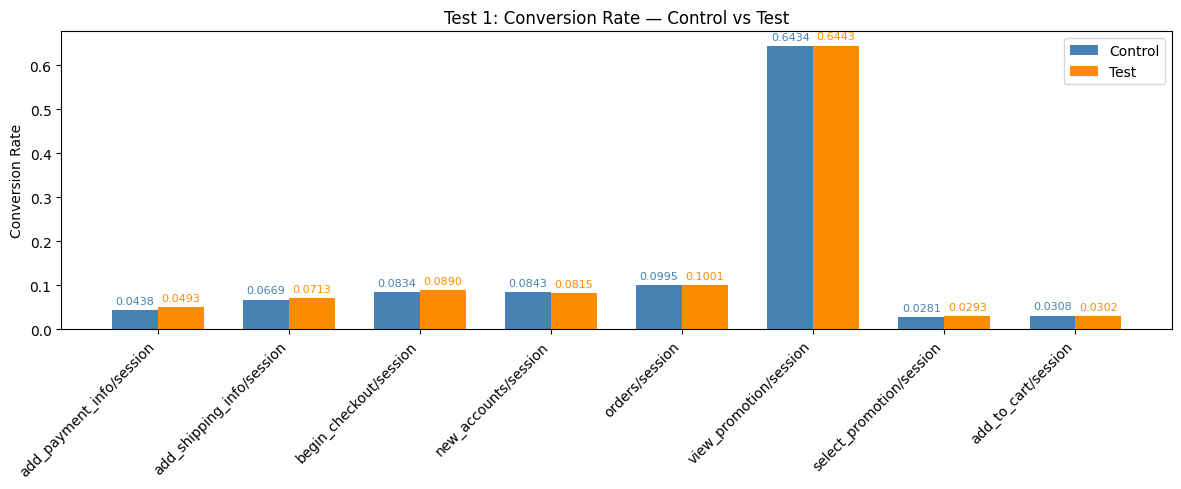

In [15]:
# Conversion Rate - Control vs Test
test1 = final_df[final_df["test_number"] == 1]
x = np.arange(len(test1))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 5))

bars_ctrl = ax.bar(x - width/2, test1["conversion_rate_control"], width,
                   label="Control", color="steelblue")
bars_test = ax.bar(x + width/2, test1["conversion_rate_test"], width,
                   label="Test", color="darkorange")

# Column captions
ax.bar_label(bars_ctrl, fmt="%.4f", label_type="edge", fontsize=8, color="steelblue", padding=3)
ax.bar_label(bars_test, fmt="%.4f", label_type="edge", fontsize=8, color="darkorange", padding=3)

ax.set_xticks(x)
ax.set_xticklabels(test1["metric"], rotation=45, ha="right")
ax.set_ylabel("Conversion Rate")
ax.set_title("Test 1: Conversion Rate — Control vs Test")
ax.legend()
plt.tight_layout()
plt.show()

## Final Results Table Explanation

This table summarizes the outcome of the A/B test for each metric.

### Columns

- __test_number__ - Identifier of the A/B test.  
- __metric__ -  Name of the metric being analyzed

#### Control Group ( group A)
- __numerator_control__ -  Number of events in the control group.  
- __denominator_control__ - Number of sessions in the control group.  
- __conversion_rate_control__ - Conversion rate in the control group (numerator_control / denominator_control).  

#### Test Group ( group B)
- __numerator_test__ - Number of events in the test group.  
- __denominator_test__ - Number of sessions in the test group.  
- __conversion_rate_test__ - Conversion rate in the test group (numerator_test / denominator_test).  

#### Comparison & Statistics
- __metric_change__ - Difference between test and control conversion rates.  
- __z_stat__ Z-statistic for the two-proportion test.  
- __p_value__ - Probability of observing such a difference under the null hypothesis.  
- __significant__ -  Boolean (True/False) indicating whether the difference is statistically significant at α = 0.05.  



### Interpretation
## Test 1 — Simplified Checkout Flow:  H₁ Confirmed

The redesigned checkout page with auto-fill and progress bar successfully
reduced friction at every measured funnel step:

- begin_checkout: 8.34% → 8.90% (+6.66%, p = 0.003) — more users entered the funnel
- add_shipping_info: 6.69% → 7.13% (+6.56%, p = 0.009) — more users completed shipping
- add_payment_info: 4.38% → 4.93% (+12.54%, p < 0.001) — strongest effect at payment stage

H₁ is confirmed: the redesign significantly improved conversion at all three
checkout steps. However, the effect did not reach the final orders/session metric,
suggesting drop-off occurs after payment info entry. Recommend rolling out the
redesign and investigating the post-payment drop-off stage.

**Decision:  Roll out**

---

## Test 2 — Promotional Banner Repositioning:  Partial, Investigate

The sticky bottom bar produced a contradictory result:

- add_to_cart: 5.55% → 6.09% (+9.75%, p < 0.001) — H₁ partially confirmed
- view_promotion: 63.92% → 63.05% (-1.36%, p = 0.004) — unexpected decline

The banner repositioning increased add-to-cart actions but reduced promotion
views. This suggests the sticky bar may be less visible as a "promotion"
but more effective as a direct CTA. H₀ is rejected, but the direction of
effect on view_promotion contradicts H₁.

**Decision:  Investigate by segment (device, channel) before rollout**

---

## Test 3 — Personalized Promotion Targeting:  H₀ Not Rejected (negative side effects)

Personalized promotions failed to improve engagement and caused measurable harm:

- view_promotion: 58.77% → 58.15% (-1.06%, p = 0.017) — fewer users saw promotions
- add_to_cart: 25.23% → 24.46% (-3.06%, p < 0.001) — fewer users added to cart
- begin_checkout: 13.61% → 13.15% (-3.35%, p = 0.012) — fewer users started checkout

H₁ is not confirmed. The personalization algorithm may have shown fewer
promotions overall, or shown irrelevant ones, reducing engagement across
the funnel.

**Decision:  Reject — personalization logic needs revision**

---

## Test 4 — Mandatory Registration Before Checkout:  H₁ Refuted

The mandatory registration gate backfired on both target metrics:

- new_accounts: 8.55% → 8.26% (-3.36%, p = 0.018) — registrations declined
- begin_checkout: 11.95% → 11.67% (-2.35%, p = 0.046) — fewer checkout starts
- view_promotion: 50.13% → 49.44% (-1.36%, p = 0.002) — reduced promo engagement

H₁ is refuted: mandatory registration did not increase new accounts — it
decreased them, likely because users abandoned the session when faced with
a forced registration wall. The checkout barrier also suppressed funnel entry.

**Decision:  Reject — the registration gate harms both acquisition and conversion**

In [16]:
summary_table = pd.DataFrame([
    {"Test": 1, "Decision": "✅ Roll out",
     "Significant metrics": "add_payment_info, add_shipping_info, begin_checkout",
     "Key reason": "Consistent positive funnel improvement"},
    {"Test": 2, "Decision": "⚠️ Investigate",
     "Significant metrics": "add_to_cart ↑, view_promotion ↓",
     "Key reason": "Mixed signals — further segmentation needed"},
    {"Test": 3, "Decision": "❌ Reject",
     "Significant metrics": "begin_checkout ↓, add_to_cart ↓, view_promotion ↓",
     "Key reason": "Negative effect on funnel and cart"},
    {"Test": 4, "Decision": "❌ Reject",
     "Significant metrics": "begin_checkout ↓, new_accounts ↓, view_promotion ↓",
     "Key reason": "Negative effect on registrations and checkout"},
])
display(summary_table)

,Test,Decision,Significant metrics,Key reason
0,1,✅ Roll out,"add_payment_info, add_shipping_info, begin_che...",Consistent positive funnel improvement
1,2,⚠️ Investigate,"add_to_cart ↑, view_promotion ↓",Mixed signals — further segmentation needed
2,3,❌ Reject,"begin_checkout ↓, add_to_cart ↓, view_promotion ↓",Negative effect on funnel and cart
3,4,❌ Reject,"begin_checkout ↓, new_accounts ↓, view_promoti...",Negative effect on registrations and checkout


 [ Link for result test](https://docs.google.com/spreadsheets/d/1dQmIGnQDPH4cuWjBLzU3253VfmBheiuPLqh6qKXuhGY/edit?gid=0#gid=0)

[Link for distribution  tableau dashboard](https://public.tableau.com/app/profile/iryna.savchuk/viz/ABportfolio1/Dashboard1?publish=yes)

[Link for significant ](https://public.tableau.com/app/profile/iryna.savchuk/viz/ABdestributionportfolio2/Calculators?publish=yes)